In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings, os
warnings.filterwarnings("ignore")

# Data preparation

In [5]:
WEATHER_PATH = "../DATA/weather.csv"
HEALTH_PATH  = "../DATA/IHME.csv"
OUT_DIR      = "../results/corr_plots"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "#f8f6f1", "axes.facecolor": "#f8f6f1",
    "axes.edgecolor": "#c8c3b8", "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "grid.color": "#e5e0d8", "grid.linewidth": 0.6,
})
RED="#c0392b"; BLUE="#1a5276"; GREEN="#1e8449"; GOLD="#b7950b"; PURPLE="#6c3483"; GRAY="#7a7570"; DARK="#1a1816"
CORR_CMAP = LinearSegmentedColormap.from_list("corr",["#1a5276","#4a90d9","#f8f6f1","#e67e22","#922b21"],N=512)

def save(fig, name):
    fig.savefig(f"{OUT_DIR}/{name}.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"  ✓  {OUT_DIR}/{name}.png"); plt.close(fig)

In [6]:
weather = pd.read_csv(WEATHER_PATH)
weather = weather[weather['year'] <= 2023]
health  = pd.read_csv(HEALTH_PATH).drop(columns = ['Deaths','Incidence'])
for frame in [weather, health]:
    for bad in ("Unnamed: 0","index"):
        if bad in frame.columns: frame.drop(columns=[bad], inplace=True)

health_wide = health.pivot_table(
    index=["country","year","income_level_mode"], columns="cause",
    values=["DALYs"], aggfunc="first").reset_index()
health_wide.columns = [
    f"{c[0]}_{c[1].replace(' ','_').replace('&','and').replace('/','_')}" if c[1] else c[0]
    for c in health_wide.columns]

df = weather.merge(health_wide, on=["country","year"], how="inner")
if "income_level_x" in df.columns:
    df.rename(columns={"income_level_x":"income_level"}, inplace=True)
    df.drop(columns=["income_level_y"], errors="ignore", inplace=True)
print(f"  Merged: {df.shape} | {df['country'].nunique()} countries | {df['year'].min()}–{df['year'].max()}")

  Merged: (1360, 47) | 40 countries | 1990–2023


In [7]:
df

,country,year,heavy_rain_days,extreme_rain_days,max_year_precip,annual_dry_area,drought_episodes,runoff_days,max_runoff,annual_freeze_burden,...,pm2.5_mean,pm2.5_uncertainty,ozone_mean,ozone_uncertainty,no2_mean,no2_uncertainty,income_level_mode,DALYs_Cardiovascular_diseases,DALYs_Chronic_respiratory_diseases,DALYs_Environmental_heat_and_cold_exposure
0,Algeria,1990,59,15,0.082610,348.501833,317,14.0,0.035023,3.016917,...,12.3,6.16,50.1,1.3,13.9,20.880,LM,11253.922792,1002.651708,10.462595
1,Algeria,1991,54,19,0.074292,349.056344,318,24.0,0.012545,7.566541,...,12.5,4.60,50.7,1.4,NaN,NaN,LM,11022.731268,986.116056,10.067621
2,Algeria,1992,46,27,0.078661,352.153994,321,22.0,0.016984,6.623073,...,12.8,4.20,50.0,1.4,NaN,NaN,LM,10816.110335,973.097973,9.733580
3,Algeria,1993,38,11,0.087847,353.177538,335,5.0,0.009068,7.721194,...,13.1,3.80,50.7,1.3,NaN,NaN,LM,10633.970031,961.796857,9.429356
4,Algeria,1994,54,23,0.060564,349.665555,320,15.0,0.015429,5.354840,...,13.5,4.00,50.5,1.3,NaN,NaN,LM,10447.598031,946.767738,9.170467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1355,Thailand,2019,229,20,0.172489,197.252966,77,26.0,0.162082,0.000000,...,24.0,2.50,45.5,1.7,10.7,24.766,LM,2925.154692,731.301871,3.935855
1356,Thailand,2020,229,15,0.228092,194.172757,82,13.0,0.217975,0.000000,...,25.2,2.70,46.3,1.7,10.4,24.792,LM,2908.572199,712.123871,3.965616
1357,Thailand,2021,250,24,0.173573,181.299715,78,18.0,0.194075,0.000000,...,23.8,2.20,NaN,NaN,NaN,NaN,LM,2946.325871,700.213233,4.000461
1358,Thailand,2022,264,36,0.276514,164.363313,49,30.0,0.249820,0.000000,...,23.7,2.40,NaN,NaN,NaN,NaN,LM,3066.742730,735.160571,4.047431


# Correlations

In [8]:
BASE_COLS = ["country", "year", "income_level_mode"]
NUM_COLS = df.select_dtypes(include="number").columns.tolist()
H_KEYS = [c for c in df.columns if c.startswith("DALYs_")]
C_KEYS = [c for c in NUM_COLS if c not in H_KEYS]

print(f"Climate vars: {len(C_KEYS)}")
print(f"Health vars: {len(H_KEYS)}")
short_c = [c.replace("_", " ")[:15] for c in C_KEYS]
short_h = [c.replace("DALYs_", "")
             .replace("Chronic_respiratory_diseases","CRD")
             .replace("Cardiovascular_diseases","Cardio")
             .replace("Environmental_heat_and_cold_exposure","Heat/Cold")
             .replace("_"," ")[:22]
           for c in H_KEYS]

Climate vars: 42
Health vars: 3


In [9]:
def corr_matrix(df_sub, x_cols, y_cols, method="pearson"):
    r_m = pd.DataFrame(index=y_cols, columns=x_cols, dtype=float)
    p_m = pd.DataFrame(index=y_cols, columns=x_cols, dtype=float)
    for y in y_cols:
        for x in x_cols:
            sub = df_sub[[x,y]].dropna()
            if len(sub) < 10: r_m.loc[y,x]=p_m.loc[y,x]=np.nan; continue
            fn = pearsonr if method=="pearson" else spearmanr
            r_m.loc[y,x], p_m.loc[y,x] = fn(sub[x], sub[y])
    return r_m.astype(float), p_m.astype(float)

def demean(df_in, cols):
    out = df_in.copy()
    for col in cols:
        if col in out.columns:
            out[col] = out[col] - out.groupby("country")[col].transform("mean")
    return out

def twoway_demean(df_in, cols):
    out = df_in.copy()
    for col in cols:
        if col in out.columns:
            out[col] = (
                out[col]
                - out.groupby("country")[col].transform("mean")
                - out.groupby("year")[col].transform("mean")
                + out[col].mean()
            )
    return out

def sig(p):
    if pd.isna(p): return ""
    return "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""

def draw_hm(ax, r_mat, p_mat, xlabels, ylabels, title="", fs=8):
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    im = ax.imshow(r_mat.values, cmap=CORR_CMAP, norm=norm, aspect="auto", interpolation="nearest")
    ax.set_xticks(range(len(xlabels))); ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=fs)
    ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels, fontsize=fs)
    ax.set_title(title, pad=8)
    for i in range(r_mat.shape[0]):
        for j in range(r_mat.shape[1]):
            r=r_mat.values[i,j]; p=p_mat.values[i,j] if p_mat is not None else np.nan
            if pd.isna(r): continue
            tc = "white" if abs(r)>0.45 else DARK
            ax.text(j,i,f"{r:.2f}{sig(p)}",ha="center",va="center",
                    fontsize=fs-0.5, color=tc, fontweight="bold" if abs(r)>0.3 else "normal")
    return im

def fisher_ci(r, n):
    if abs(r)>=1 or n<4: return r, r
    z=np.arctanh(r); se=1/np.sqrt(n-3); zc=stats.norm.ppf(0.975)
    return np.tanh(z-zc*se), np.tanh(z+zc*se)

r_pearson, p_pearson = corr_matrix(df, C_KEYS, H_KEYS, "pearson")
r_spearman, p_spearman = corr_matrix(df, C_KEYS, H_KEYS, "spearman")
df_within = demean(df, C_KEYS + H_KEYS)
r_within, p_within = corr_matrix(df_within, C_KEYS, H_KEYS, "pearson")
df_tw = twoway_demean(df, C_KEYS + H_KEYS)
r_tw, p_tw = corr_matrix(df_tw, C_KEYS, H_KEYS, "pearson")

Let's take only significant correlations.

In [10]:
alpha = 0.05

r_pearson = r_pearson.mask(p_pearson > alpha)
r_spearman = r_spearman.mask(p_spearman > alpha)
r_within = r_within.mask(p_within > alpha)
r_tw = r_tw.mask(p_tw > alpha)

In [11]:
r_pearson

,year,heavy_rain_days,extreme_rain_days,max_year_precip,annual_dry_area,drought_episodes,runoff_days,max_runoff,annual_freeze_burden,anomaly_cold_days,...,annual_potential_evap,mean_annual_rsn,evap_deficit,winter_mean_snow_density,pm2.5_mean,pm2.5_uncertainty,ozone_mean,ozone_uncertainty,no2_mean,no2_uncertainty
DALYs_Cardiovascular_diseases,-0.228521,-0.310247,NaN,-0.244081,0.371229,0.439023,0.454795,-0.245918,-0.122720,0.109035,...,0.114781,-0.229298,NaN,-0.162302,0.375885,0.252662,0.265400,0.076226,-0.153760,NaN
DALYs_Chronic_respiratory_diseases,-0.167176,0.093709,NaN,0.170521,0.056119,NaN,0.055264,0.116694,-0.308420,0.142223,...,-0.181913,-0.370608,0.150774,-0.417265,0.543967,0.361261,NaN,0.123194,-0.313443,NaN
DALYs_Environmental_heat_and_cold_exposure,-0.107855,-0.116895,NaN,-0.219604,0.154461,NaN,-0.068492,-0.189512,0.288938,NaN,...,0.288828,0.141374,-0.257397,0.232783,NaN,0.128990,0.119086,-0.124201,NaN,0.153052


In [12]:
r_spearman

,year,heavy_rain_days,extreme_rain_days,max_year_precip,annual_dry_area,drought_episodes,runoff_days,max_runoff,annual_freeze_burden,anomaly_cold_days,...,annual_potential_evap,mean_annual_rsn,evap_deficit,winter_mean_snow_density,pm2.5_mean,pm2.5_uncertainty,ozone_mean,ozone_uncertainty,no2_mean,no2_uncertainty
DALYs_Cardiovascular_diseases,-0.265355,-0.235895,-0.056742,-0.109784,0.272357,0.325287,0.139084,-0.150790,-0.174078,0.133368,...,NaN,-0.213902,0.068962,-0.191850,0.522916,0.397567,0.107949,0.173669,-0.381779,-0.160931
DALYs_Chronic_respiratory_diseases,-0.175749,0.219999,NaN,0.280162,NaN,NaN,0.159345,0.214607,-0.395491,0.162074,...,-0.293414,-0.447961,0.243915,-0.479757,0.548995,0.410486,-0.187154,0.208939,-0.421977,-0.166934
DALYs_Environmental_heat_and_cold_exposure,-0.131234,-0.073987,-0.061981,-0.121816,0.225611,0.177276,-0.100026,-0.122580,0.083807,NaN,...,0.098285,0.062939,NaN,NaN,NaN,0.091326,-0.072430,-0.133089,-0.267933,-0.226350


## Visualizations

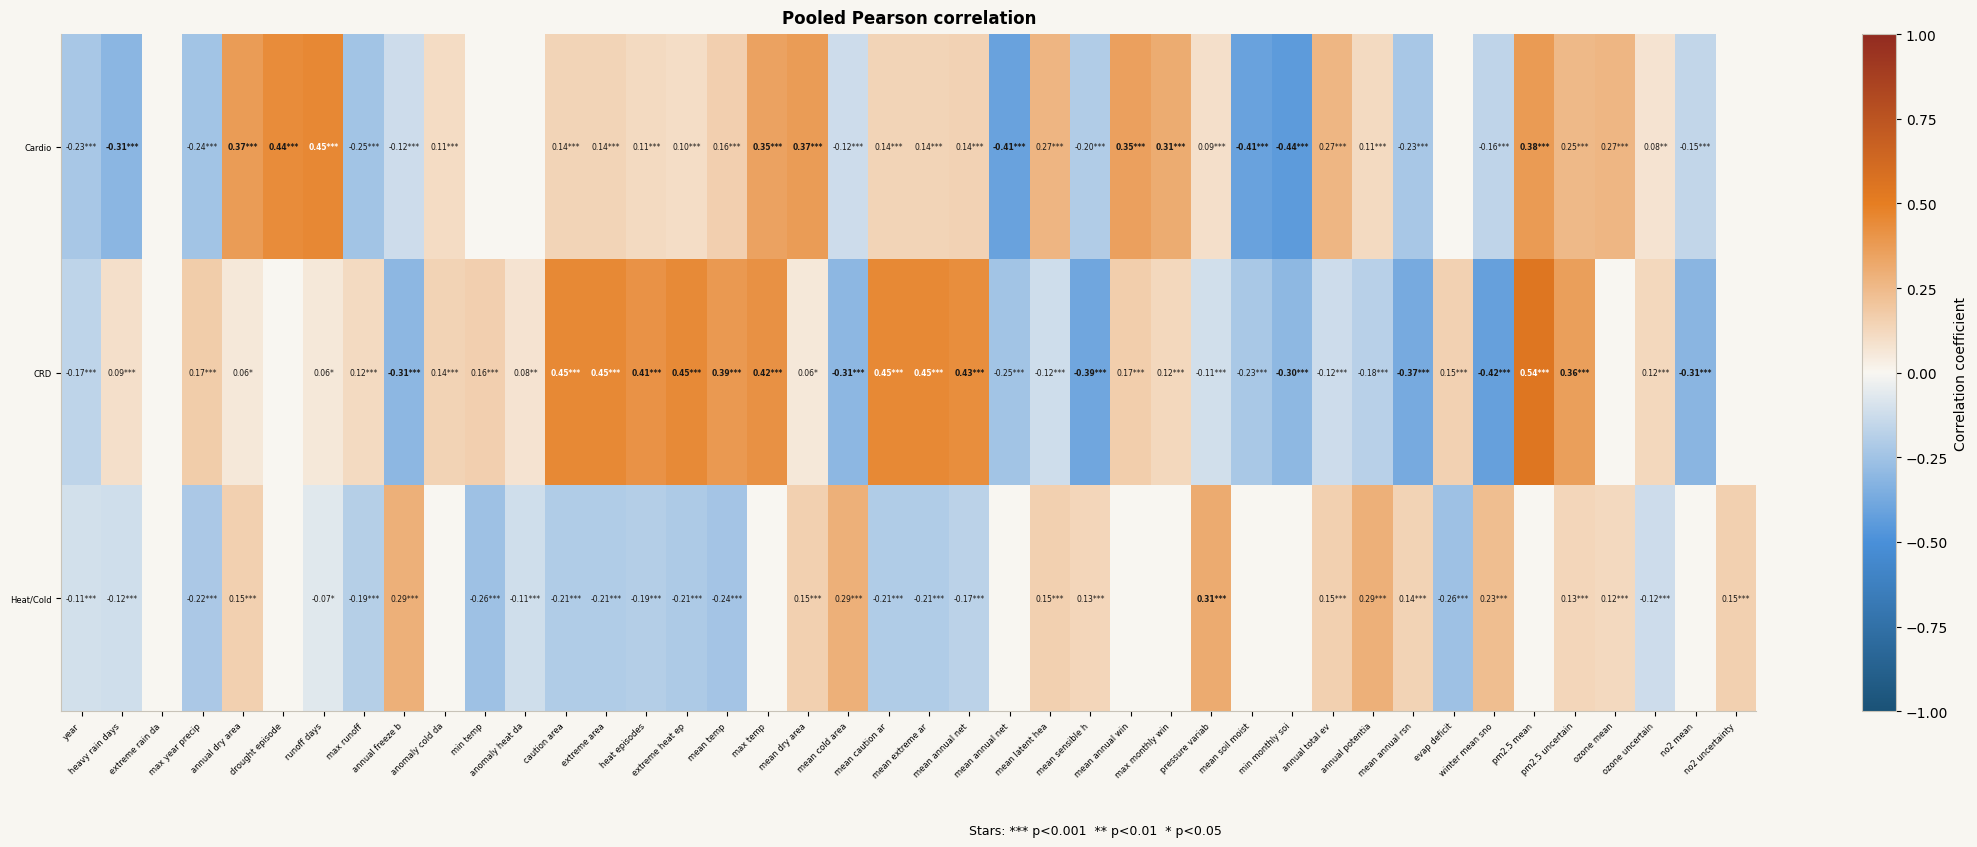

In [13]:
fs_cell = max(6, 9 - len(C_KEYS)//4)
W = min(22, len(C_KEYS)*1.35+4); H = max(8, len(H_KEYS)*0.9+4)
fig, ax = plt.subplots(figsize=(W, H))

im = draw_hm(ax, r_pearson, p_pearson, short_c, short_h, "Pooled Pearson correlation", fs_cell)

cb = fig.colorbar(im, ax=ax)
cb.set_label("Correlation coefficient")

fig.text(
    0.5, -0.05,
    "Stars: *** p<0.001  ** p<0.01  * p<0.05",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    "../results/corr_plots/pooled_pearson.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

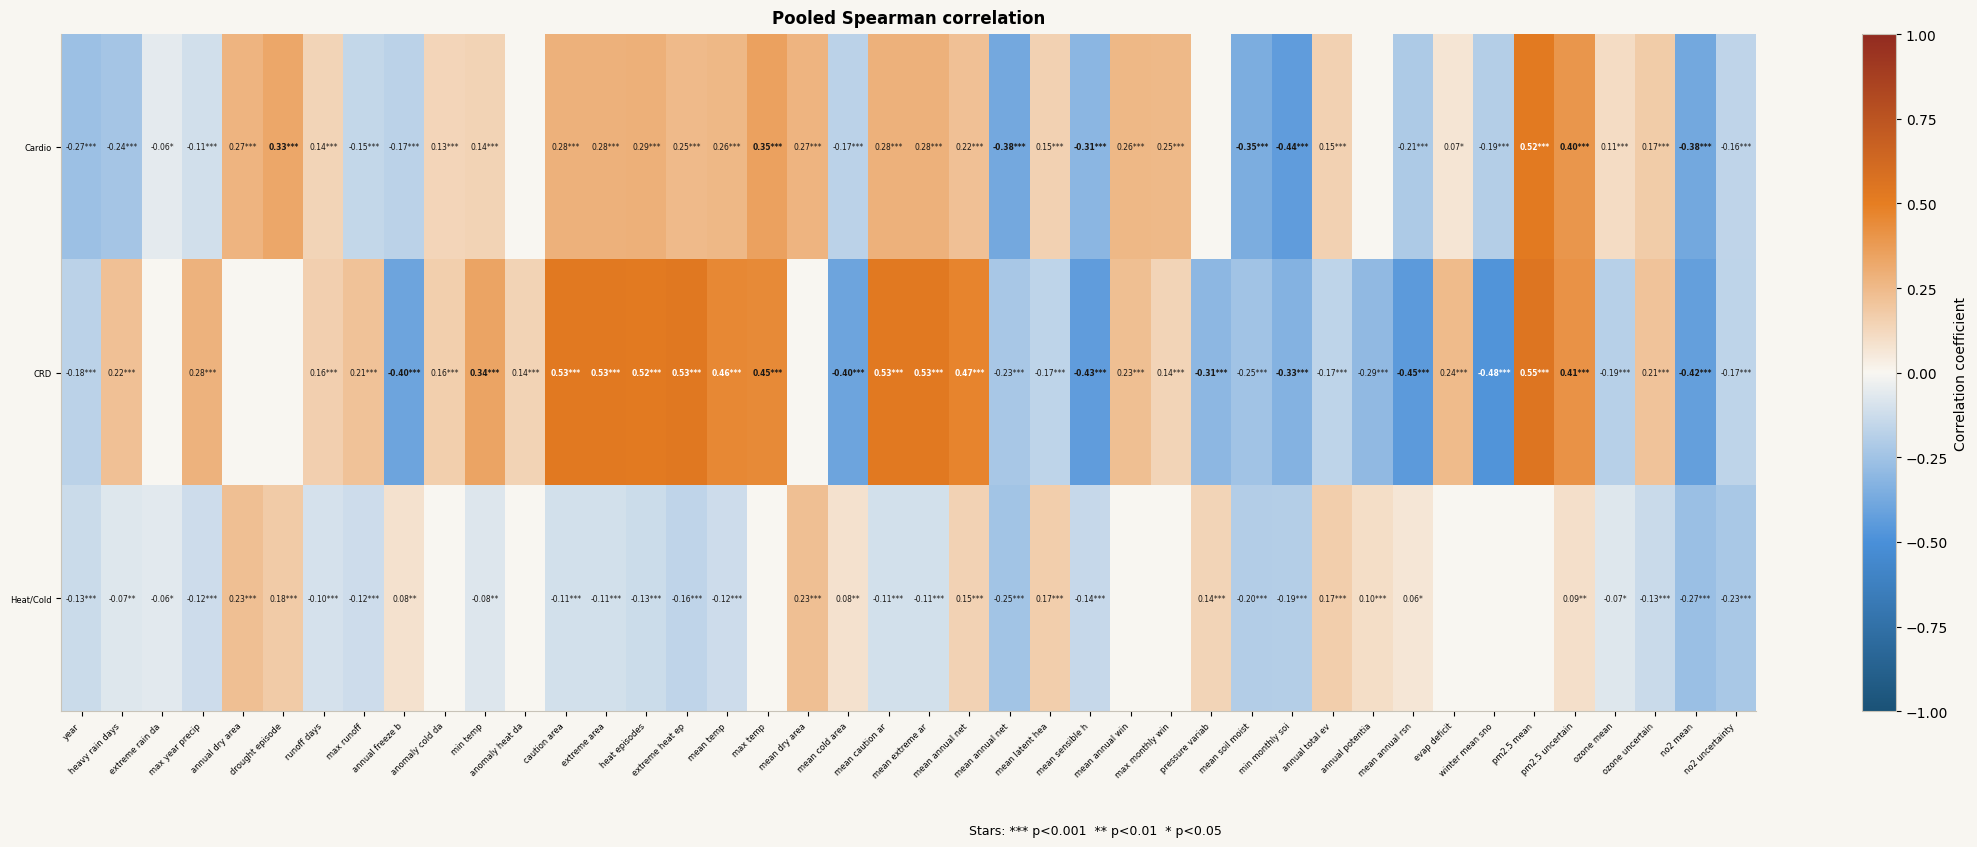

In [14]:
fig, ax = plt.subplots(figsize=(W, H))

im = draw_hm(ax, r_spearman, p_spearman, short_c, short_h, "Pooled Spearman correlation", fs_cell)

cb = fig.colorbar(im, ax=ax)
cb.set_label("Correlation coefficient")

fig.text(
    0.5, -0.05,
    "Stars: *** p<0.001  ** p<0.01  * p<0.05",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    "../results/corr_plots/pooled_spearman.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

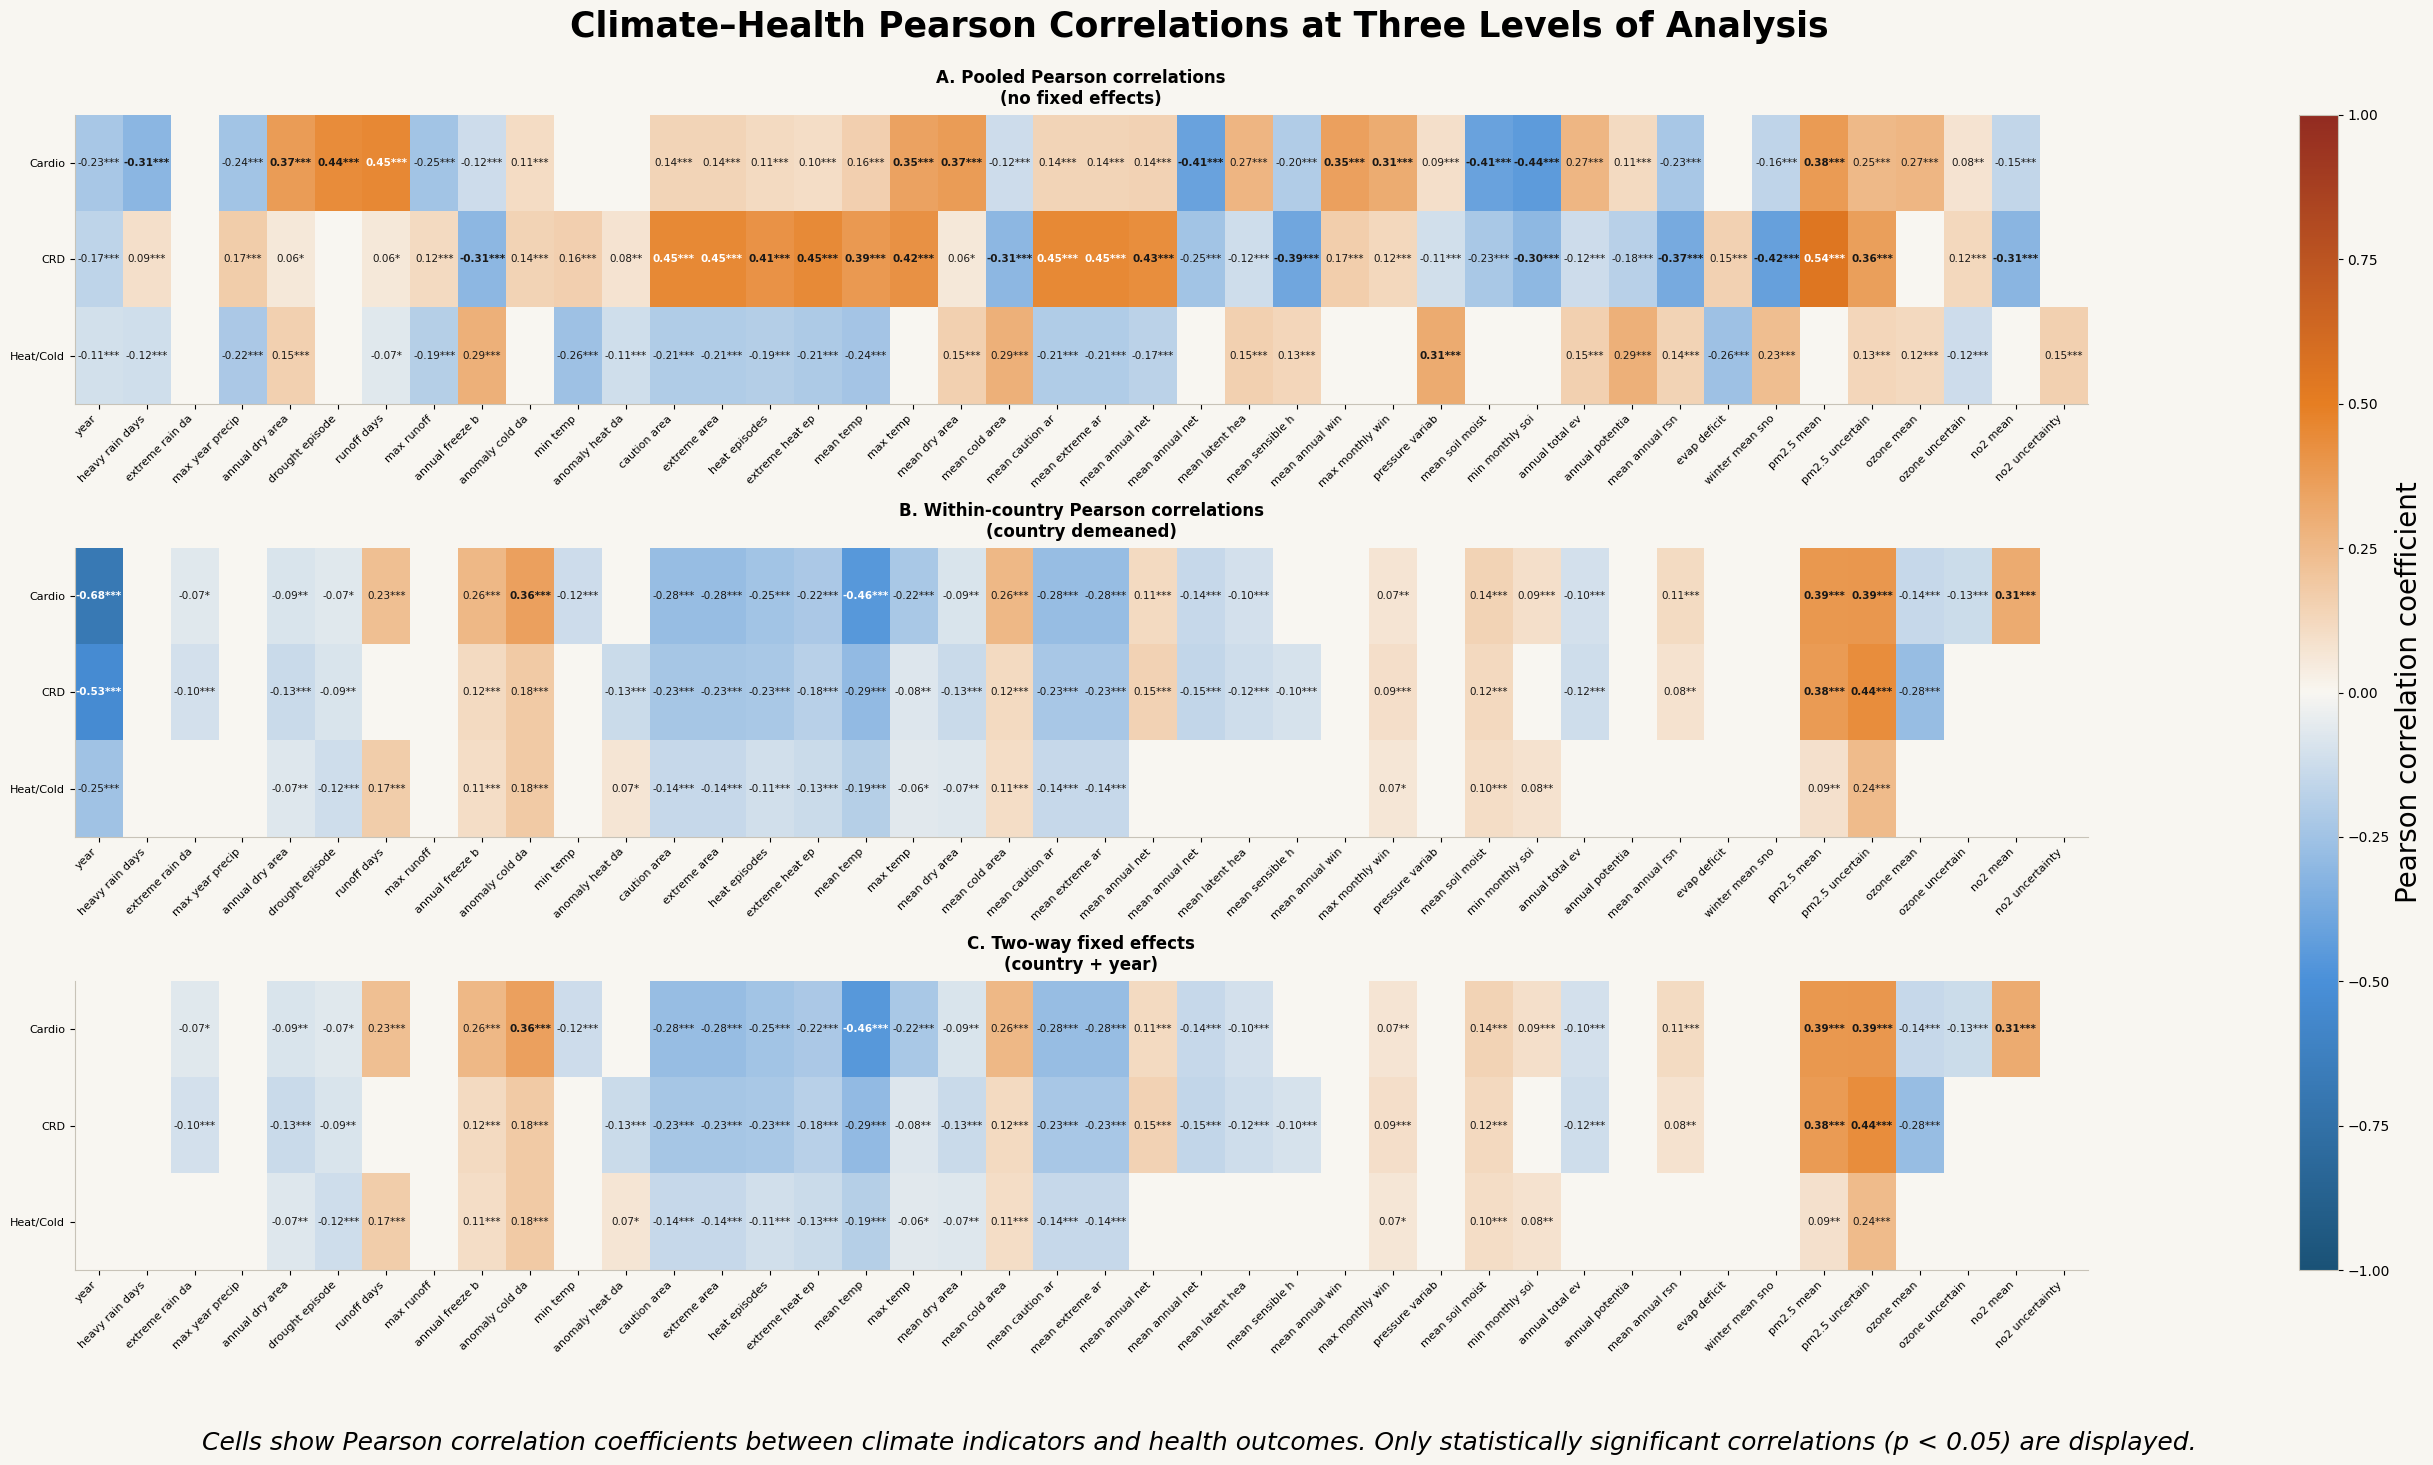

In [15]:
fs_cell = max(8, 12 - len(C_KEYS)//5)

fig_width = 30
fig_height = 15

fig = plt.figure(figsize=(fig_width, fig_height))
fig.suptitle(
    "Climate–Health Pearson Correlations at Three Levels of Analysis",
    fontsize=25, fontweight="bold", y=0.95
)

gs = gridspec.GridSpec(3, 2, hspace=0.5, width_ratios=[1, 0.05])
ax1, ax2, ax3 = [fig.add_subplot(gs[i,0]) for i in range(3)]
axc = fig.add_subplot(gs[:,1])
axc.axis("off")

draw_hm(ax1, r_pearson, p_pearson, short_c, short_h,
        "A. Pooled Pearson correlations\n(no fixed effects)", fs_cell)
draw_hm(ax2, r_within, p_within, short_c, short_h,
        "B. Within-country Pearson correlations\n(country demeaned)", fs_cell)
im = draw_hm(ax3, r_tw, p_tw, short_c, short_h,
             "C. Two-way fixed effects\n(country + year)", fs_cell)

cb = fig.colorbar(im, ax=axc, fraction=1.0, pad=0.05, aspect=30)
cb.set_label("Pearson correlation coefficient", fontsize=20)

fig.text(
    0.5, -0.01,
    "Cells show Pearson correlation coefficients between climate indicators "
    "and health outcomes. Only statistically significant correlations (p < 0.05) are displayed.",
    ha="center",
    fontsize=18,
    style="italic"
)

fig.tight_layout(rect=[0,0,1,0.97])
plt.savefig(
    "../results/corr_plots/corr_levels.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [16]:
r_within_sp, p_within_sp = corr_matrix(df_within, C_KEYS, H_KEYS, "spearman")
r_tw_sp, p_tw_sp = corr_matrix(df_tw, C_KEYS, H_KEYS, "spearman")
alpha = 0.05
r_within_sp = r_within_sp.mask(p_within_sp > alpha)
r_tw_sp = r_tw_sp.mask(p_tw_sp > alpha)

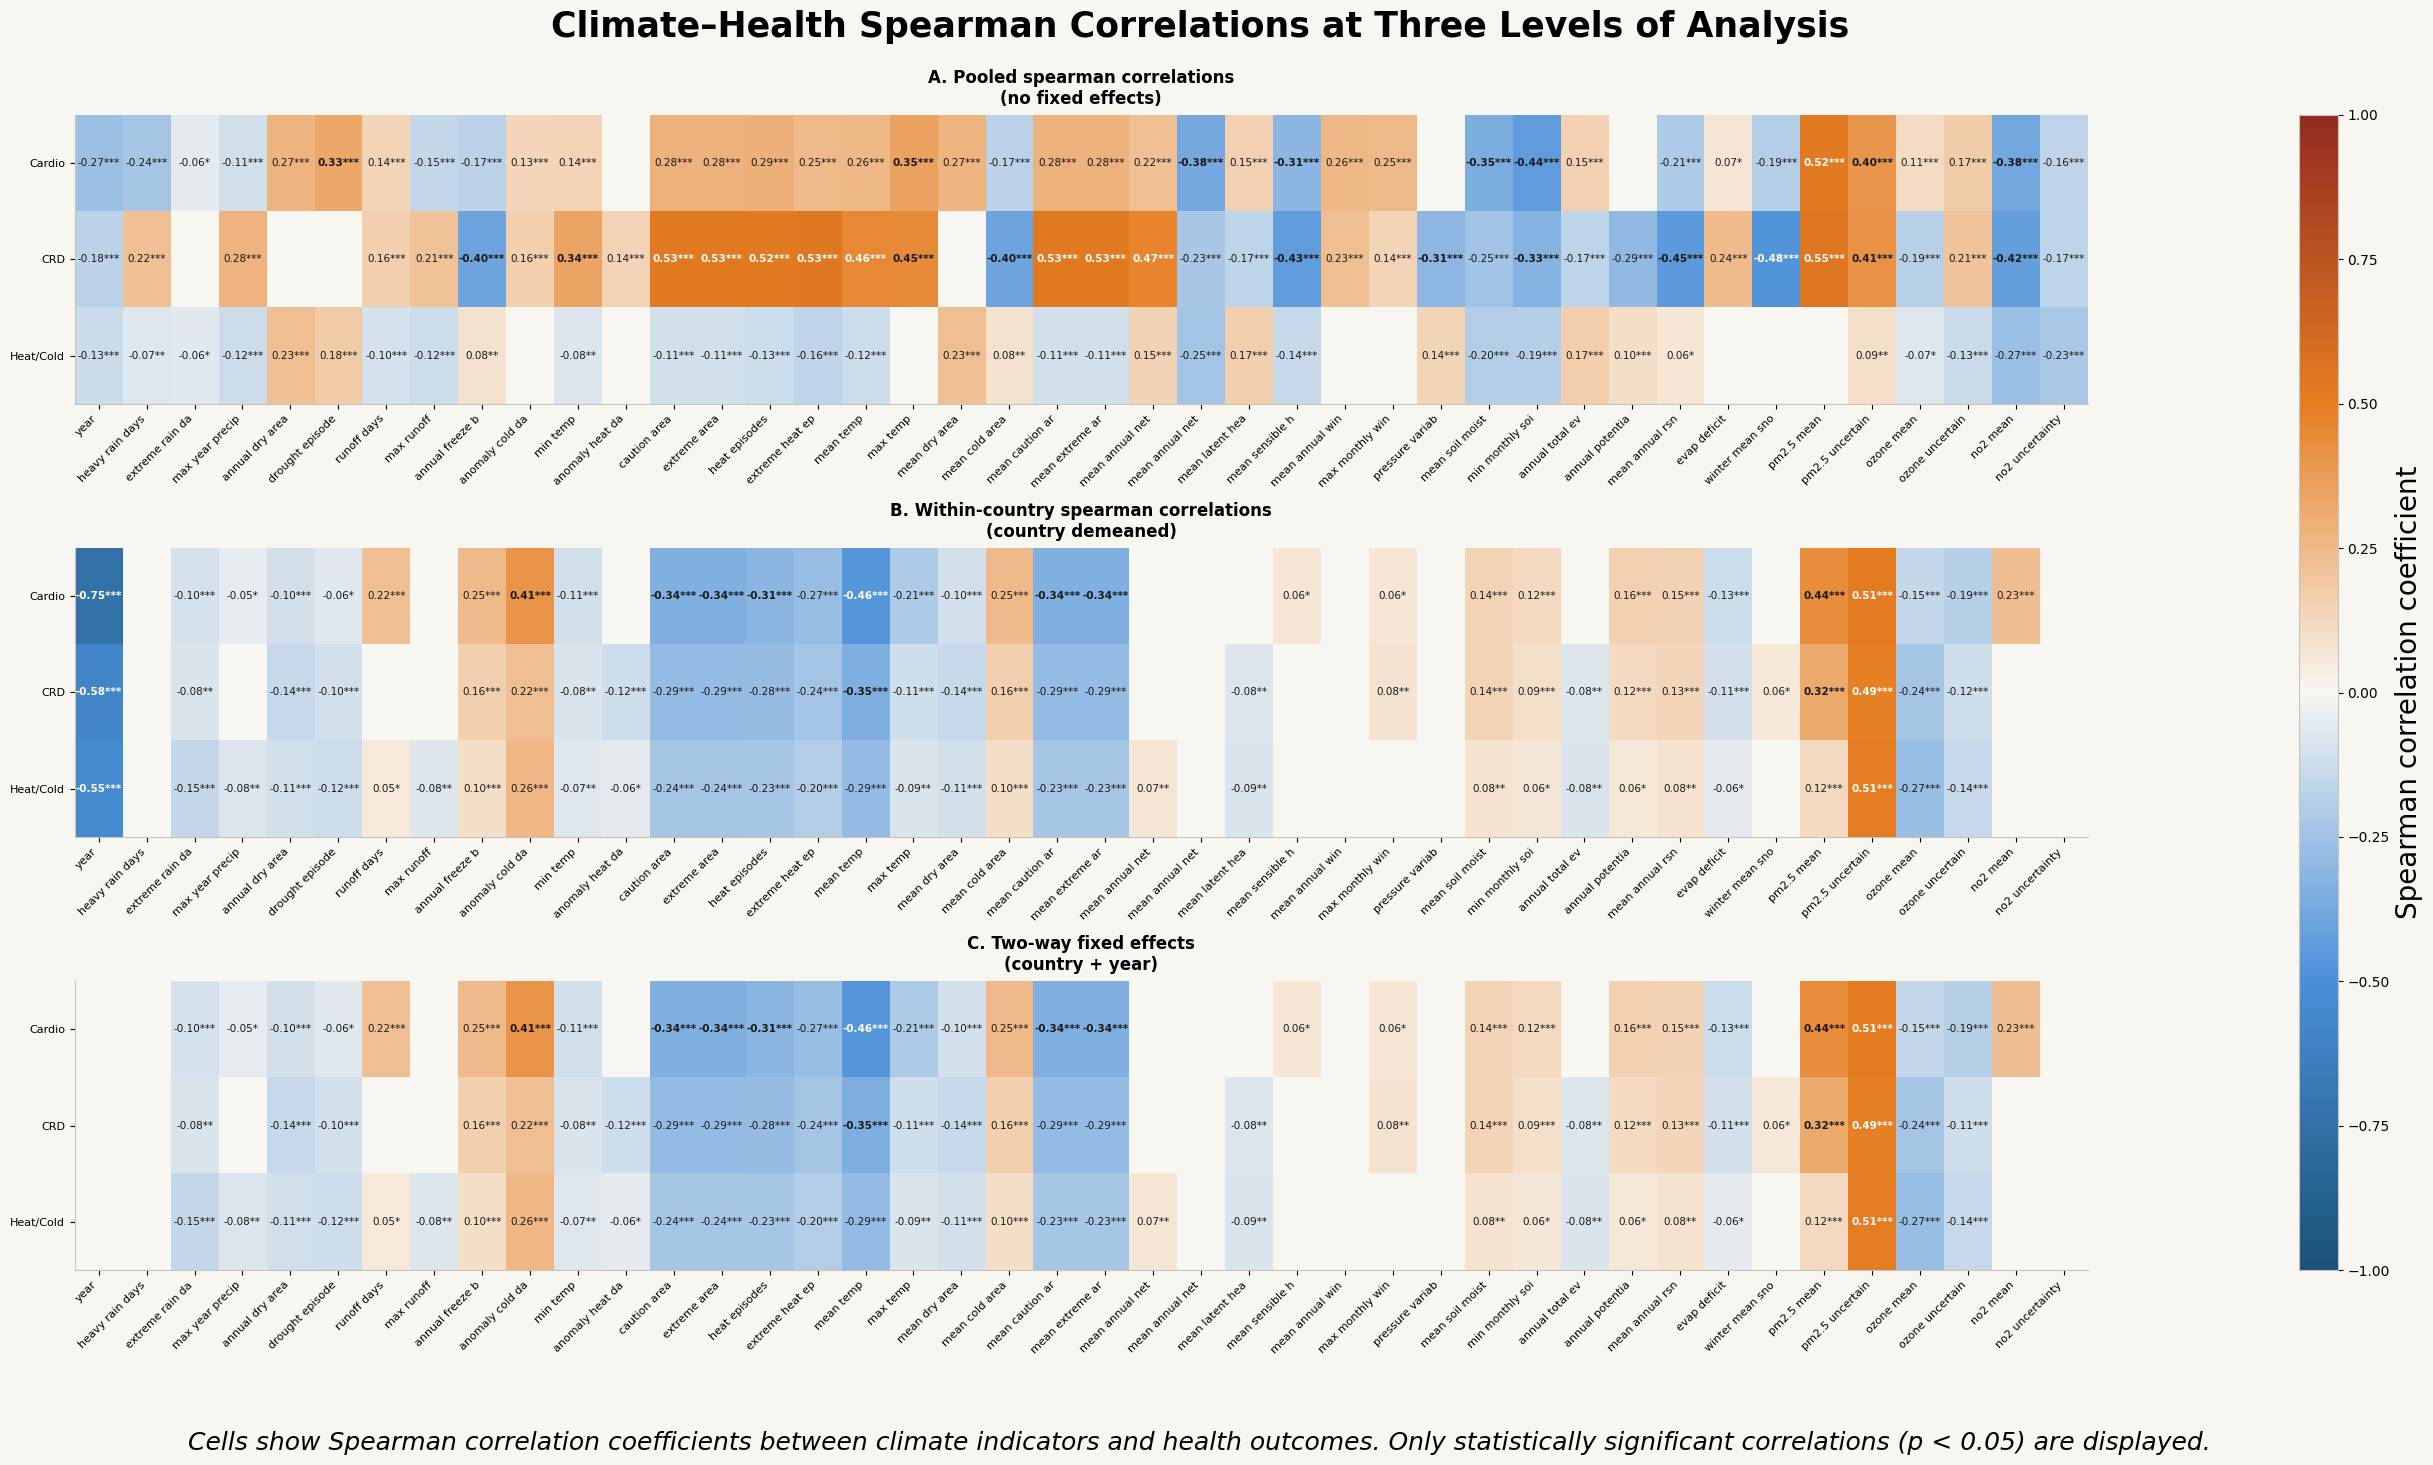

In [17]:
fs_cell = max(8, 12 - len(C_KEYS)//5)

fig_width = 30
fig_height = 15

fig = plt.figure(figsize=(fig_width, fig_height))
fig.suptitle(
    "Climate–Health Spearman Correlations at Three Levels of Analysis",
    fontsize=25, fontweight="bold", y=0.95
)

gs = gridspec.GridSpec(3, 2, hspace=0.5, width_ratios=[1, 0.05])
ax1, ax2, ax3 = [fig.add_subplot(gs[i,0]) for i in range(3)]
axc = fig.add_subplot(gs[:,1])
axc.axis("off")

draw_hm(ax1, r_spearman, p_spearman, short_c, short_h,
        "A. Pooled spearman correlations\n(no fixed effects)", fs_cell)
draw_hm(ax2, r_within_sp, p_within_sp, short_c, short_h,
        "B. Within-country spearman correlations\n(country demeaned)", fs_cell)
im = draw_hm(ax3, r_tw_sp, p_tw_sp, short_c, short_h,
             "C. Two-way fixed effects\n(country + year)", fs_cell)

cb = fig.colorbar(im, ax=axc, fraction=1.0, pad=0.05, aspect=30)
cb.set_label("Spearman correlation coefficient", fontsize=20)

fig.text(
    0.5, -0.01,
    "Cells show Spearman correlation coefficients between climate indicators "
    "and health outcomes. Only statistically significant correlations (p < 0.05) are displayed.",
    ha="center",
    fontsize=18,
    style="italic"
)

fig.tight_layout(rect=[0,0,1,0.97])
plt.savefig(
    "../results/corr_plots/corr_levels_sp.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [18]:
delta_trend = (r_tw - r_within).astype(float)
max_change = delta_trend.abs().max().max()
print("Max Δtrend:", max_change)
print((delta_trend.abs() > 0.05).any().any())

Max Δtrend: 1.1102230246251565e-16
False


**Year fixed effects do not materially change correlations**

Although DALYs exhibit a strong negative time trend, removing year effects through two-way transformation does not materially change the climate–health correlations (max Δ ≈ 0). This suggests that the observed associations are not driven by common temporal trends.

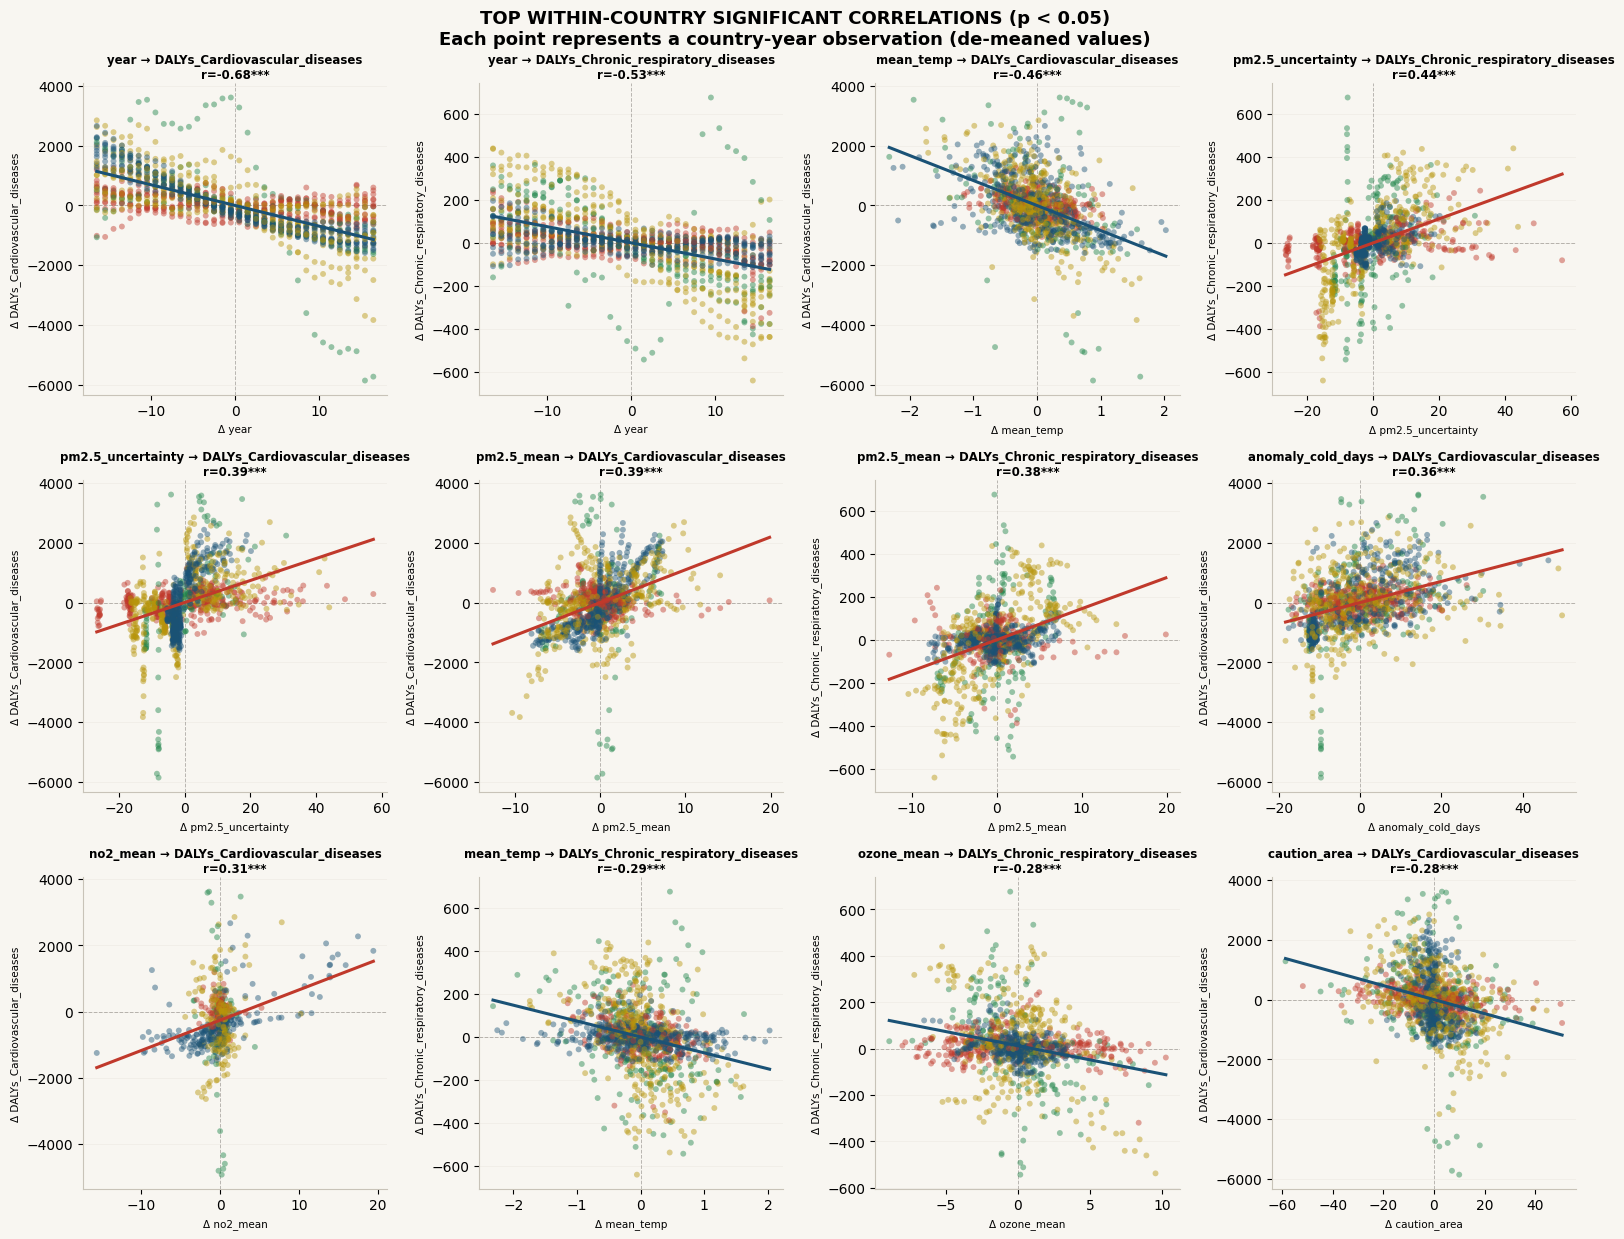

In [19]:
pairs=[(abs(r_within.loc[y,x]),r_within.loc[y,x],p_within.loc[y,x],x,y)
       for y in H_KEYS for x in C_KEYS
       if pd.notna(r_within.loc[y,x])
       and pd.notna(p_within.loc[y,x])
       and p_within.loc[y,x]<0.05]

pairs.sort(reverse=True)
top12=pairs[:12]

if top12:

    ncols=4
    nrows=(len(top12)+ncols-1)//ncols

    fig,axes=plt.subplots(nrows,ncols,
                          figsize=(16,nrows*4.2),
                          squeeze=False)

    fig.suptitle(
        "TOP WITHIN-COUNTRY SIGNIFICANT CORRELATIONS (p < 0.05)\n"
        "Each point represents a country-year observation (de-meaned values)",
        fontsize=13,fontweight="bold"
    )

    inc_col={"L":RED,"LM":GOLD,"UM":GREEN,"H":BLUE}

    for idx,(absr,r,p,x_col,y_col) in enumerate(top12):

        ax=axes[idx//ncols][idx%ncols]
        sub=df_within[[x_col,y_col,"income_level_mode"]].dropna()

        ax.scatter(
            sub[x_col],
            sub[y_col],
            c=sub["income_level_mode"].map(inc_col).fillna(GRAY),
            alpha=0.45,
            s=18,
            zorder=3,
            edgecolors="none"
        )

        sl,ic,*_=stats.linregress(sub[x_col],sub[y_col])
        xl=np.linspace(sub[x_col].min(),sub[x_col].max(),100)
        ax.plot(xl,sl*xl+ic,
                color=RED if r>0 else BLUE,
                lw=2.2,zorder=4)

        ax.axhline(0,color=GRAY,lw=0.7,ls="--",alpha=0.5)
        ax.axvline(0,color=GRAY,lw=0.7,ls="--",alpha=0.5)

        ax.set_title(
            f"{x_col} → {y_col}\nr={r:.2f}{sig(p)}",
            fontsize=8.5,pad=4
        )

        ax.set_xlabel(f"Δ {x_col}",fontsize=7.5)
        ax.set_ylabel(f"Δ {y_col}",fontsize=7.5)

        ax.yaxis.grid(True,zorder=0,alpha=0.4)

    for idx in range(len(top12),nrows*ncols):
        axes[idx//ncols][idx%ncols].set_visible(False)

    fig.tight_layout()
    plt.savefig(
        "../results/corr_plots/signif_corr.png",
        dpi=300,
        bbox_inches="tight"
    )

The scatterplots confirm that the strongest correlations are not driven by a small number of extreme observations and generally display approximately linear patterns. This supports the use of linear correlation measures and suggests that the identified associations reflect systematic within-country relationships rather than statistical artifacts.

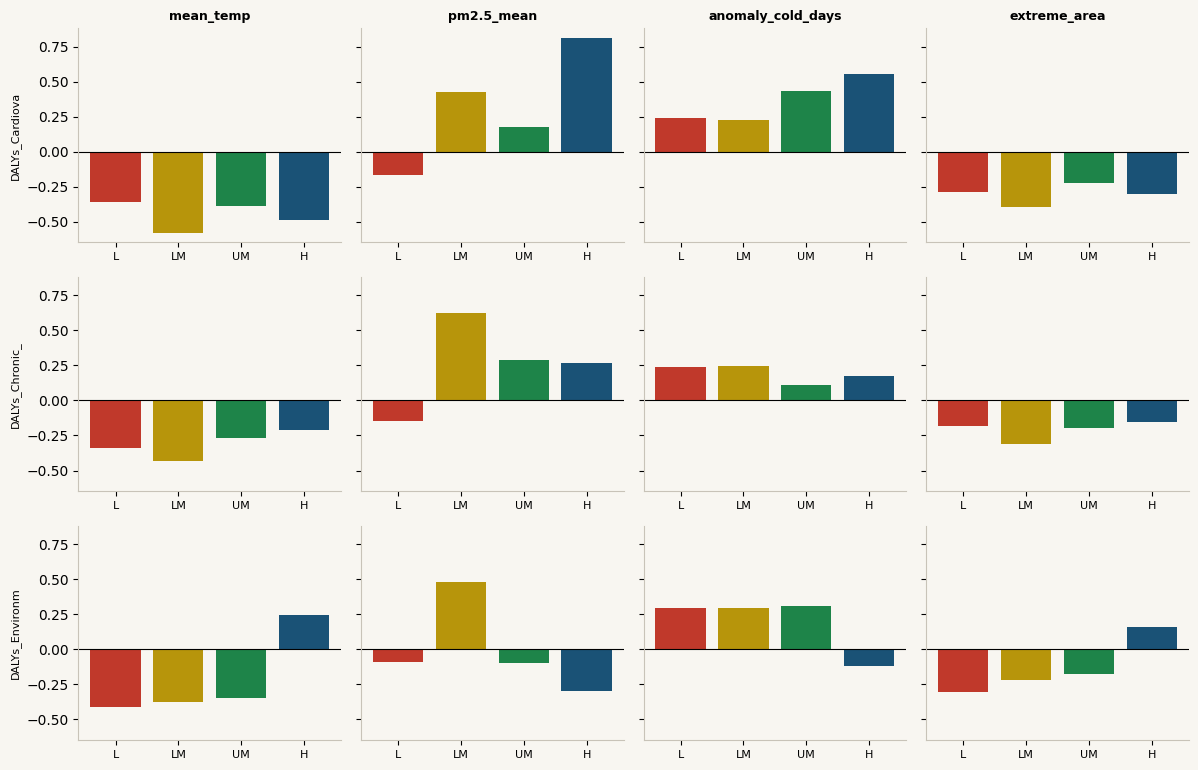

In [20]:
climate_vars = [
    "mean_temp",
    "pm2.5_mean",
    "anomaly_cold_days",
    "extreme_area"
]
health_vars = [c for c in df_within.columns if "DALYs" in c][:4]

incomes = ["L","LM","UM","H"]
income_colors = {"L":RED,"LM":GOLD,"UM":GREEN,"H":BLUE}

fig, axes = plt.subplots(len(health_vars), len(climate_vars),
                         figsize=(len(climate_vars)*3, len(health_vars)*2.6),
                         sharey=True)

for hi, y in enumerate(health_vars):
    for ci, x in enumerate(climate_vars):

        ax = axes[hi][ci]

        rs = []

        for inc in incomes:
            sub = df_within[df_within["income_level_mode"]==inc][[x,y]].dropna()

            if len(sub) < 10:
                rs.append(0)
                continue

            r,_ = pearsonr(sub[x],sub[y])
            rs.append(r)

        ax.bar(range(4), rs,
               color=[income_colors[i] for i in incomes])

        ax.axhline(0,color="black",lw=0.8)

        ax.set_xticks(range(4))
        ax.set_xticklabels(incomes,fontsize=8)

        if hi==0:
            ax.set_title(x,fontsize=9)

        if ci==0:
            ax.set_ylabel(y[:14],fontsize=8)

plt.tight_layout()
plt.savefig(
        "../results/corr_plots/corr_income_distr.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()
        
